In [1]:
!pip install einops albumentations torchinfo

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
#Generate Dataset
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=3,
    n_informative=3, # Increased n_informative to satisfy make_classification constraints
    random_state=42
)

y_onehot = np.eye(3)[y]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_onehot,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)
print(y_train.shape)

(800, 10)
(800, 3)


In [4]:
#Activation Functions
def relu(x):
    return np.maximum(0,x)


def relu_derivative(x):
    return (x>0).astype(float)


def softmax(x):
    exp = np.exp(
        x - np.max(x,axis=1,keepdims=True)
    )
    return exp / np.sum(
        exp,
        axis=1,
        keepdims=True
    )



In [5]:
#Initialize Network Parameters
np.random.seed(42)


W1 = np.random.randn(10,32)*0.01
b1 = np.zeros((1,32))


W2 = np.random.randn(32,16)*0.01
b2 = np.zeros((1,16))


W3 = np.random.randn(16,3)*0.01
b3 = np.zeros((1,3))


learning_rate = 0.01

In [6]:
#Forward Propagation

def forward(X):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    output = softmax(Z3)

    cache = (Z1,A1,Z2,A2,Z3)

    return output,cache

In [7]:

#Cross Entropy Loss
def cross_entropy(y_pred,y_true):

    loss = -np.sum(
        y_true*np.log(y_pred+1e-9)
    )

    return loss/y_true.shape[0]

In [8]:

#Backpropagation
def backward(X,y,cache):

    global W1,W2,W3,b1,b2,b3

    Z1,A1,Z2,A2,Z3 = cache


    m = X.shape[0]


    dZ3 = (forward(X)[0]-y)/m


    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3,axis=0,keepdims=True)


    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)


    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2,axis=0,keepdims=True)


    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)


    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1,axis=0,keepdims=True)



    W1 -= learning_rate*dW1
    W2 -= learning_rate*dW2
    W3 -= learning_rate*dW3


    b1 -= learning_rate*db1
    b2 -= learning_rate*db2
    b3 -= learning_rate*db3

In [9]:
#Training Loop
loss_history=[]


for epoch in range(100):

    prediction,cache = forward(X_train)

    loss = cross_entropy(
        prediction,
        y_train
    )

    backward(
        X_train,
        y_train,
        cache
    )

    loss_history.append(loss)


    if epoch%10==0:
        print(
            "Epoch:",
            epoch,
            "Loss:",
            loss
        )


Epoch: 0 Loss: 1.0986212769395325
Epoch: 10 Loss: 1.0986150449073522
Epoch: 20 Loss: 1.0986092284194393
Epoch: 30 Loss: 1.0986037298441946
Epoch: 40 Loss: 1.0985986546812074
Epoch: 50 Loss: 1.0985939857947993
Epoch: 60 Loss: 1.0985896270301712
Epoch: 70 Loss: 1.0985855481769582
Epoch: 80 Loss: 1.0985817425334017
Epoch: 90 Loss: 1.0985781811679567


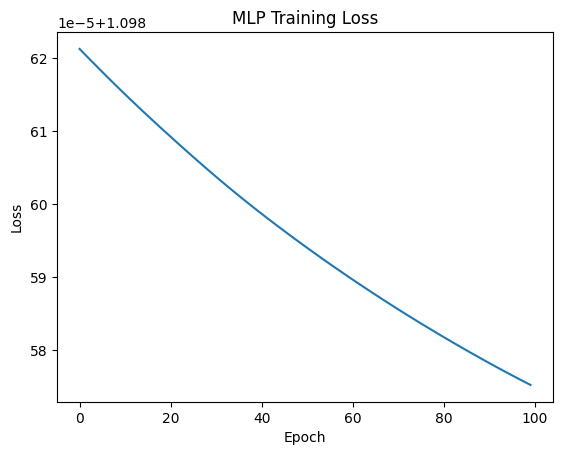

In [10]:

#Loss Visualization
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")

plt.show()

In [11]:
#Accuracy
pred,_ = forward(X_test)


accuracy = np.mean(
    np.argmax(pred,axis=1)
    ==
    np.argmax(y_test,axis=1)
)


print(
    "Test Accuracy:",
    accuracy
)



Test Accuracy: 0.325
